In [3]:
from __future__ import annotations

# Standard library imports
from pathlib import Path

# Third-party imports
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Local application imports
from privtree import privtree_grid
from sldp_opt_utils import run_dp_quadtree_optimized

# Jupyter/IPython configuration
%config InlineBackend.figure_format = 'retina'

In [ ]:
rng = np.random.default_rng()

def generate_clustered_data(n_samples=10_000, bounds=(0, 0, 1, 1)):
    """
    Generates points grouped into clusters (simulating cities),
    using Rejection Sampling to stay within bounds.
    """
    xmin, ymin, xmax, ymax = bounds
    
    # "City" centers (x, y) and their "spread" (sigma)
    centers = [
        (0.2, 0.2, 0.05), # City 1
        (0.8, 0.8, 0.05), # City 2
        (0.5, 0.5, 0.10), # Large area in the center
        (0.2, 0.8, 0.04), # Small city
        (0.8, 0.2, 0.04)  # Small city
    ]
    
    X_list = []
    
    # Evenly distribute the required number of points across centers
    n_centers = len(centers)
    counts = [n_samples // n_centers] * n_centers
    # Distribute the remainder across the first clusters
    for i in range(n_samples % n_centers):
        counts[i] += 1
    
    for (cx, cy, sigma), n_needed in zip(centers, counts):
        cluster_points = []
        while len(cluster_points) < n_needed:
            # How many more are needed
            missing = n_needed - len(cluster_points)
            
            # Generate with a margin (x1.5) to enter the loop less frequently
            batch_size = int(missing * 1.5) + 10
            
            # Generate candidates
            candidates = rng.normal(loc=(cx, cy), scale=sigma, size=(batch_size, 2))
            
            # Check conditions (Rejection step)
            # Keep only those strictly within bounds
            mask = (candidates[:, 0] >= xmin) & (candidates[:, 0] <= xmax) & \
                   (candidates[:, 1] >= ymin) & (candidates[:, 1] <= ymax)
            
            accepted = candidates[mask]
            cluster_points.extend(accepted)
        
        # Trim excess if we generated slightly more, and save
        X_list.append(np.array(cluster_points[:n_needed]))
    
    # Combine all clusters into a single array
    X = np.vstack(X_list)
    
    # (Optional) Shuffle so that clusters are not sequential
    rng.shuffle(X)
    
    return X


def generate_query_rectangles(n_queries=10, min_side=0.1, max_side=0.3, bounds=(0,0,1,1)):
    """
    Generates random rectangles (queries) that we will answer.
    Format: [[x1, y1, x2, y2], ...]
    """
    xmin, ymin, xmax, ymax = bounds
    queries = []
    
    for _ in range(n_queries):
        # Random width and height
        w = rng.uniform(min_side, max_side)
        h = rng.uniform(min_side, max_side)
        
        # Random bottom-left corner (ensuring the rectangle fits within bounds)
        x1 = rng.uniform(xmin, xmax - w)
        y1 = rng.uniform(ymin, ymax - h)
        
        queries.append([x1, y1, x1+w, y1+h])
        
    return np.array(queries)

In [5]:
## SLDP Quadtree

def _as_rect_list(raw):
    """
    Converts the QuadTree algorithm output (which can be a list of objects,
    a list of lists, or a numpy array) into a flat list of objects
    that have x_min, y_min, x_max, y_max attributes.
    """
    rects = []
    
    def collect(item):
        # 1. If it is already an object with attributes (e.g., from sldp_opt_utils)
        if hasattr(item, "x_min"):
            rects.append(item)
            return

        # 2. If it is a list/array
        if isinstance(item, (list, tuple, np.ndarray)):
            arr = np.array(item)
            # Check if this looks like coordinates of a single leaf [x1, y1, x2, y2]
            # Criteria: length 4 and contains numbers
            is_coords = (
                arr.size == 4 and 
                arr.ndim == 1 and 
                (arr.size > 0 and isinstance(arr.item(0) if arr.dtype != object else item[0], (int, float, np.number)))
            )
            
            if is_coords:
                # Create a "fake" object so the code continues to work uniformly
                rects.append(type('Leaf', (object,), {
                    'x_min': float(arr[0]), 'y_min': float(arr[1]), 
                    'x_max': float(arr[2]), 'y_max': float(arr[3])
                })())
            else:
                # If it is a list of lists, dig deeper (recursion)
                for sub in item:
                    collect(sub)

    if raw is not None:
        collect(raw)
        
    return rects



def build_quadtree_synopsis(X, eps, bounds=(0,0,1,1)):
    # IMPORTANT: Call your actual run_dp_quadtree_optimized function here
    raw_leaves = run_dp_quadtree_optimized(X, eps/2, Q=20, C = 6.0, T=10, delta=0.05, bounds=bounds, rng=rng)
    cells = _as_rect_list(raw_leaves)
    cells = np.array([[l.x_min, l.y_min, l.x_max, l.y_max] for l in cells], dtype=float)    

    # SLDP Logic: Leaf size determines the noise
    leaf_sizes = np.maximum(cells[:,2]-cells[:,0], cells[:,3]-cells[:,1])
    eps_query = eps / 2
    noise_scales = leaf_sizes / eps_query
    
    noisy_counts = np.zeros(len(cells))
    for i in range(len(cells)):
        c = cells[i]
        # Who is inside?
        n_users = ((X[:,0]>=c[0])&(X[:,0]<c[2])&(X[:,1]>=c[1])&(X[:,1]<c[3])).sum()
        if n_users > 0:
            # User-centric noise: everyone adds noise
            noisy_counts[i] = n_users + rng.laplace(0, noise_scales[i], size=n_users).sum()
            
    return cells, np.maximum(noisy_counts, 0)


## PrivTree

def build_privtree_synopsis(X, eps, bounds=(0,0,1,1)):
    eps_tree = eps/2
    eps_data = eps/2
    # gamma = 8.0
    # lam = (2*np.exp(gamma)-1)/(np.exp(gamma)-1)/(eps_tree)
    # delta = gamma * lam
    # theta = 0
    lam = (7.0) / (3 * eps_tree)
    delta = lam * np.log(4.0)
    theta=0
    cells = privtree_grid(X,bounds, lam, theta, delta)


    noisy_counts = np.zeros(len(cells))
    for i in range(len(cells)):
        c = cells[i]
        # Who is inside?
        n_users = ((X[:,0]>=c[0])&(X[:,0]<c[2])&(X[:,1]>=c[1])&(X[:,1]<c[3])).sum()
        # User-centric noise: everyone adds noise
        noisy_counts[i] = n_users + rng.laplace(0, 1/eps_data)
            
    return cells, np.maximum(noisy_counts, 0)


## LDP Kd-Tree

def build_ldp_kdtree_synopsis(
    X,
    eps,
    bounds=(0.0, 0.0, 1.0, 1.0),
    max_depth=5,
    alpha=20,
    rng=None,
):
    """
    LDP Kd-Tree, updated according to Algorithm 6 (CALC_MED).
    """
    if rng is None:
        rng = np.random.default_rng()

    X = np.asarray(X, dtype=float)
    # The budget is divided by levels, since we query the histogram at each level
    eps_per_level = eps / max_depth

    cells = []

    def split_node(subset: np.ndarray, bnds, depth: int, parent_density: float):
        xmin, ymin, xmax, ymax = bnds

        # 1. Depth check (stopping condition)
        if depth >= max_depth:
            # In the leaf, save the density passed from the parent
            cells.append([xmin, ymin, xmax, ymax, parent_density])
            return

        # Define axis: Algorithm 4, line 5
        axis = depth % 2  # 0 -> X, 1 -> Y
        current_min = xmin if axis == 0 else ymin
        current_max = xmax if axis == 0 else ymax

        # --- Start of Algorithm 5 / Algorithm 6 implementation ---
        
        # Build buckets
        bucket_edges = np.linspace(current_min, current_max, alpha + 1)
        values = subset[:, axis]
        
        # Get true counts (part of Server-side computation)
        hist, _ = np.histogram(values, bins=bucket_edges)

        # Add noise (LDP step)
        noise_scale = 1.0 / eps_per_level
        noisy_hist = hist + rng.laplace(0.0, noise_scale, size=len(hist))

        # Algorithm 6: CALC_MED Function
        
        # Line 1: dsum <- Sum of densities of all buckets
        dsum = np.sum(noisy_hist)
        
        # Line 6: currsum <- 0
        currsum = 0.0
        
        split_val = (current_min + current_max) / 2.0 # fallback
        c1 = dsum / 2.0 # fallback
        c2 = dsum / 2.0 # fallback
        
        # Line 7: for j = 1 to |relbuckets| do
        found_median = False
        for k in range(len(noisy_hist)):
            # Line 8-9: den <- density of bucket
            den = noisy_hist[k]
            
            # Line 10: currsum <- currsum + den
            currsum += den
            
            # Line 11: if currsum >= dsum/2 then
            if currsum >= dsum / 2.0:
                # Line 12-17: Retrieve max/min of bucket and calc med
                # bucket_edges[k] is the bucket min, bucket_edges[k+1] is the max
                bucket_min = bucket_edges[k]
                bucket_max = bucket_edges[k+1]
                
                # med <- (max + min)/2
                split_val = (bucket_min + bucket_max) / 2.0
                
                # Line 19: c1 <- currsum - floor(den/2)
                # Use floor, as in the paper
                c1 = currsum - np.floor(den / 2.0)
                
                # Line 20: c2 <- dsum - c1
                c2 = dsum - c1
                
                found_median = True
                # Line 18: break
                break
        
        # If the loop finished but median wasn't found (e.g., dsum <= 0 due to noise),
        # use fallback values (uniform split), but the paper assumes
        # the median will be found.
        
        if not found_median:
             # Edge case if dsum <= 0 due to heavy noise or logic break
             pass 

        # Data splitting for recursion (Algorithm 4, lines 13-15)
        if axis == 0:  # X axis
            mask_left = subset[:, 0] < split_val
            left_bounds  = (xmin, ymin, split_val, ymax)
            right_bounds = (split_val, ymin, xmax, ymax)

            # Recursive call with new densities c1 and c2
            split_node(subset[mask_left],  left_bounds,  depth + 1, c1)
            split_node(subset[~mask_left], right_bounds, depth + 1, c2)

        else:  # Y axis
            mask_bottom = subset[:, 1] < split_val
            bottom_bounds = (xmin, ymin, xmax, split_val)
            top_bounds    = (xmin, split_val, xmax, ymax)

            # Recursive call with new densities c1 and c2
            split_node(subset[mask_bottom],  bottom_bounds, depth + 1, c1)
            split_node(subset[~mask_bottom], top_bounds,    depth + 1, c2)

    initial_N = len(X)
    # Start with initial density (although at level 1 it will be recalculated via dsum)
    split_node(X, bounds, 0, float(initial_N))

    cells_arr = np.array([c[:4] for c in cells], dtype=float)
    counts_arr = np.array([c[4] for c in cells], dtype=float)

    # Return max(0), as Laplace noise can yield negative values,
    # but physical density meaning is >= 0.
    return cells_arr, np.maximum(counts_arr, 0.0)


In [6]:
def answer_range_queries(queries, cells, counts):
    """
    Accepts:
      queries: (M, 4) list of queries [[x1, y1, x2, y2], ...]
      cells:   (N, 4) list of cells [[x1, y1, x2, y2], ...]
      counts:  (N,)   noisy count of people in each cell
      
    Returns:
      answers: (M,)   answers for each query (sum of fractions)
    """
    answers = []
    
    # 1. Pre-calculate the area of each cell (Cell Area)
    # Width * Height
    cell_areas = (cells[:, 2] - cells[:, 0]) * (cells[:, 3] - cells[:, 1])
    # Protection against division by zero (if a cell collapsed)
    cell_areas = np.maximum(cell_areas, 1e-12)
    
    # 2. Iterate through each query
    for q in queries: # q = [qx1, qy1, qx2, qy2]
        
        # Vectorized intersection calculation:
        # Compare current query q with ALL cells at once
        
        # Intersection coordinates (Intersection Box)
        ix1 = np.maximum(cells[:, 0], q[0])
        iy1 = np.maximum(cells[:, 1], q[1])
        ix2 = np.minimum(cells[:, 2], q[2])
        iy2 = np.minimum(cells[:, 3], q[3])
        
        # Intersection width and height (0 if no intersection)
        iw = np.maximum(0, ix2 - ix1)
        ih = np.maximum(0, iy2 - iy1)
        
        intersect_areas = iw * ih
        
        # 3. Calculate ratio: What fraction of the cell falls into the query?
        ratios = intersect_areas / cell_areas
        
        # 4. Final answer = Sum (Cell_count * Ratio)
        est = np.sum(counts * ratios)
        answers.append(est)
        
    return np.array(answers)


# First, calculate TRUE answers (Ground Truth) for comparison
def get_true_answers(X, queries):
    true_ans = []
    for q in queries:
        mask = (X[:,0] >= q[0]) & (X[:,0] < q[2]) & (X[:,1] >= q[1]) & (X[:,1] < q[3])
        true_ans.append(mask.sum())
    return np.array(true_ans)

##Synthetic dataset

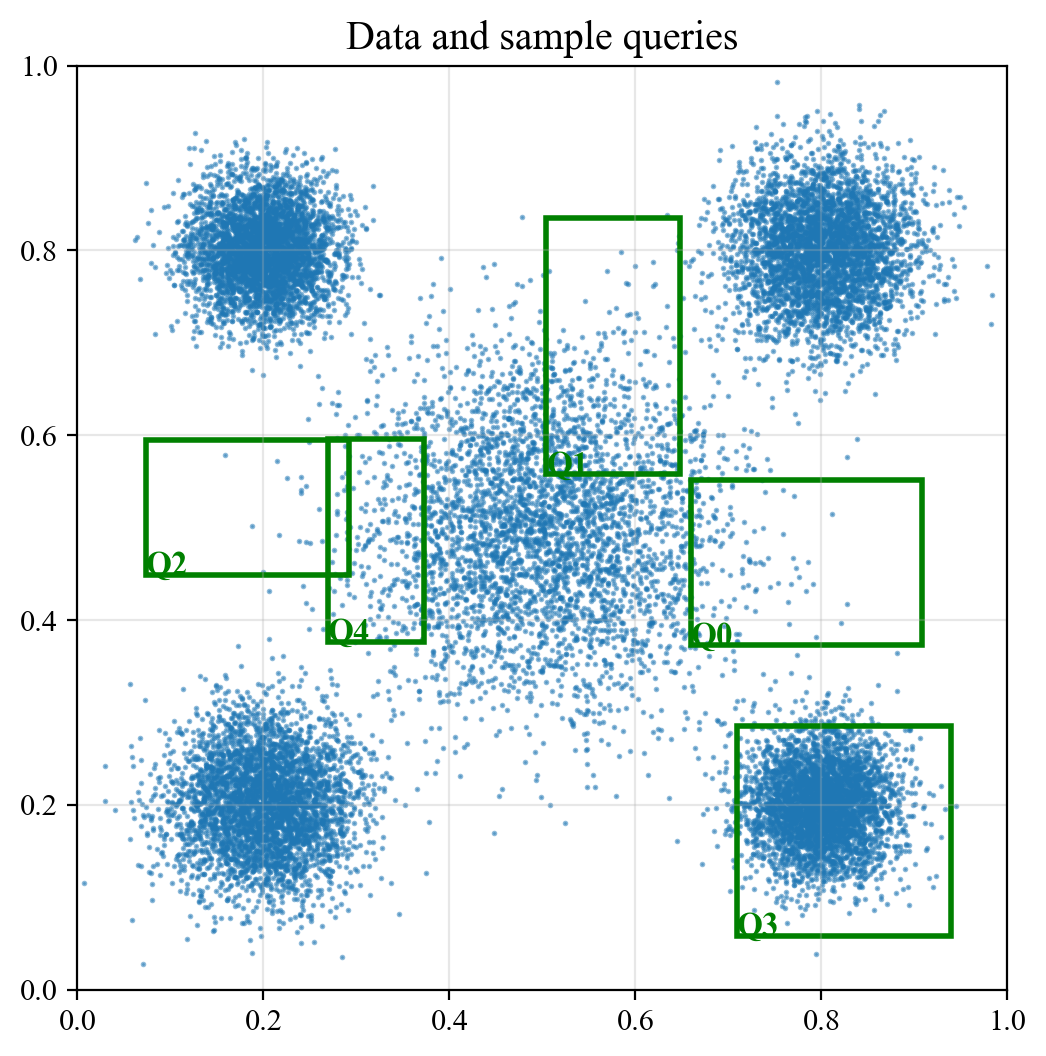

Points generated: (20000, 2)
Queries generated: (5, 4)
Example of one query (x1, y1, x2, y2): [0.65921953 0.37252847 0.9076983  0.55159571]


In [28]:
# --- EXECUTION AND VISUALIZATION ---

# 1. Generate 20,000 points
X = generate_clustered_data(n_samples=20000)

# 2. Generate 5 test queries (counting areas)
queries = generate_query_rectangles(n_queries=5)

# Visualization for verification
fig, ax = plt.subplots(figsize=(6, 6))
# Plot points
ax.scatter(X[:, 0], X[:, 1], s=1, alpha=0.5, label='Users (Data)')

# Plot queries (green rectangles)
for i, q in enumerate(queries):
    # q = [x1, y1, x2, y2]
    rect = patches.Rectangle(
        (q[0], q[1]), q[2]-q[0], q[3]-q[1], 
        linewidth=2, edgecolor='green', facecolor='none'
    )
    ax.add_patch(rect)
    ax.text(q[0], q[1], f"Q{i}", color='green', fontsize=12, weight='bold')

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_title("Data and sample queries")
plt.show()

print(f"Points generated: {X.shape}")
print(f"Queries generated: {queries.shape}")
print("Example of one query (x1, y1, x2, y2):", queries[0])

In [8]:
# --- Experiment Settings ---

# 1. Dataset sizes (N) - each N will get its own subplot
N_values = [5000, 10000, 20000]

# 2. Privacy budgets (epsilon) - this will be the X-axis
eps_values = [0.1, 0.5, 1.0, 2.0, 3.0]

# 3. Repetitions for confidence intervals
n_repeats = 50 

# 4. Other parameters
n_queries = 100       
bounds = (0, 0, 1, 1)

# Storage for results
results = []

def safe_mre(y_true, y_pred):
    """
    Calculates Mean Relative Error (MRE).
    """
    y_t = np.array(y_true)
    y_p = np.array(y_pred)
    # Avoid division by zero by using max(y_t, threshold)
    return np.mean(np.abs(y_p - y_t) / np.maximum(y_t, n * 0.0001))

print(f"Starting experiments...")
print(f"N values: {N_values}")
print(f"Epsilon values: {eps_values}")

# --- Main Experiment Loop ---
for n in N_values:
    for eps in eps_values:
        # Progress indicator
        print(f"Running: N={n}, epsilon={eps} ...")
        
        for r in range(n_repeats):
            # 1. Generate data and queries
            # Regenerate data to average out topological effects
            X = generate_clustered_data(n_samples=n, bounds=bounds)
            queries = generate_query_rectangles(n_queries=n_queries, bounds=bounds)
            
            # Ground Truth
            y_true = get_true_answers(X, queries)
            
            # --- Algorithm 1: PrivTree ---
            cells_pt, counts_pt = build_privtree_synopsis(X, eps, bounds)
            y_pt = answer_range_queries(queries, cells_pt, counts_pt)
            mre_pt = safe_mre(y_true, y_pt)
            results.append({
                'N': n,
                'Epsilon': eps,
                'Algorithm': 'PrivTree',
                'MRE': mre_pt
            })
            
            # --- Algorithm 2: LDP Kd-Tree ---
            cells_kd, counts_kd = build_ldp_kdtree_synopsis(X, eps, bounds, max_depth=16)
            y_kd = answer_range_queries(queries, cells_kd, counts_kd)
            mre_kd = safe_mre(y_true, y_kd)
            results.append({
                'N': n,
                'Epsilon': eps,
                'Algorithm': 'LDP Kd-Tree',
                'MRE': mre_kd
            })
            
            # --- Algorithm 3: SLDP QuadTree (Our Method) ---
            cells_qt, counts_qt = build_quadtree_synopsis(X, eps, bounds)
            y_qt = answer_range_queries(queries, cells_qt, counts_qt)
            mre_qt = safe_mre(y_true, y_qt)
            results.append({
                'N': n,
                'Epsilon': eps,
                'Algorithm': 'SLDP QuadTree',
                'MRE': mre_qt
            })

# Convert results to DataFrame
df_res = pd.DataFrame(results)


Starting experiments...
N values: [5000, 10000, 20000]
Epsilon values: [0.1, 0.5, 1.0, 2.0, 3.0]
Running: N=5000, epsilon=0.1 ...
Running: N=5000, epsilon=0.5 ...
Running: N=5000, epsilon=1.0 ...
Running: N=5000, epsilon=2.0 ...
Running: N=5000, epsilon=3.0 ...
Running: N=10000, epsilon=0.1 ...
Running: N=10000, epsilon=0.5 ...
Running: N=10000, epsilon=1.0 ...
Running: N=10000, epsilon=2.0 ...
Running: N=10000, epsilon=3.0 ...
Running: N=20000, epsilon=0.1 ...
Running: N=20000, epsilon=0.5 ...
Running: N=20000, epsilon=1.0 ...
Running: N=20000, epsilon=2.0 ...
Running: N=20000, epsilon=3.0 ...


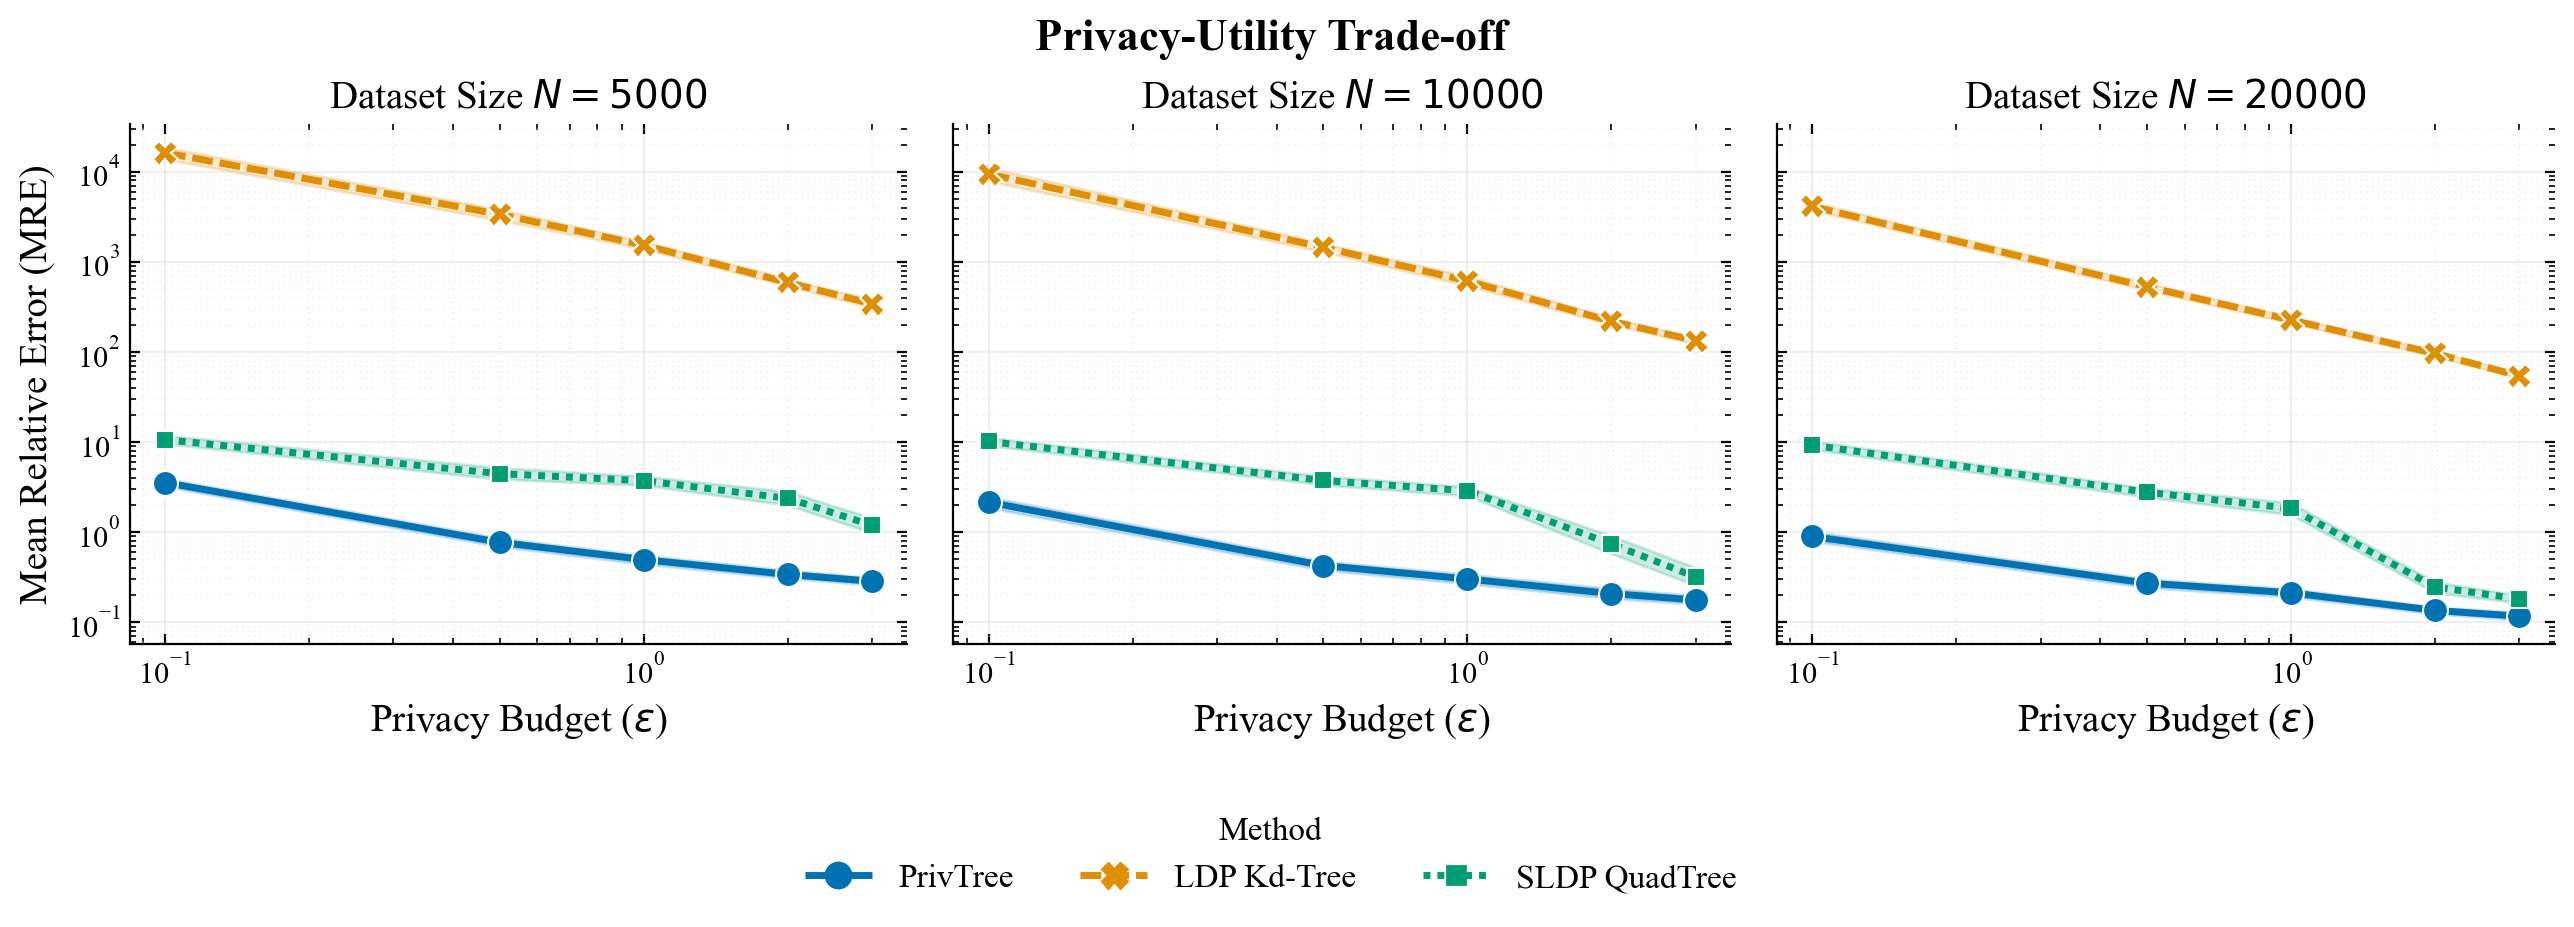

In [9]:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "axes.labelsize": 14,     # Slightly larger for readability
    "font.size": 12,
    "legend.fontsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "lines.linewidth": 2.5,   # Thicker lines for visibility
    "axes.grid": True,        # Grid is essential for scientific plots
    "grid.alpha": 0.3,        # Subtle grid lines
    "text.usetex": False      # Set to True if you have a local LaTeX installation
})

# --- Plotting ---
# Define line styles manually to ensure distinction in B/W printing
# (Solid, Dashed, Dotted, Dash-dot)
unique_algos = df_res['Algorithm'].unique()
# Map each algorithm to a specific dash pattern
dashes_map = {algo: style for algo, style in zip(unique_algos, [(1,0), (3,1), (1,1), (3,1,1,1)])}

g = sns.relplot(
    data=df_res,
    x="Epsilon", 
    y="MRE",
    hue="Algorithm", 
    style="Algorithm",
    col="N",
    kind="line",
    palette="colorblind", # Colorblind-friendly palette
    markers=True,
    markersize=9,         # Clear markers
    dashes=dashes_map,    # Explicit line styles
    height=4,             # Height of each subplot
    aspect=1.1,           # Width/Height ratio
    facet_kws={'sharey': True, 'legend_out': False} # We handle the legend manually
)

# --- Styling Axes ---
# Use LaTeX notation for mathematical symbols in labels
g.set_axis_labels(r"Privacy Budget ($\varepsilon$)", "Mean Relative Error (MRE)")
g.set_titles(r"Dataset Size $N = {col_name}$")

# Log scales are standard for privacy/error plots
g.set(yscale="log")
g.set(xscale="log") 

# Fine-tune ticks and grid
for ax in g.axes.flat:
    # Enable major and minor grids
    ax.grid(True, which="major", ls="-", color='0.8')
    ax.grid(True, which="minor", ls=":", color='0.9')
    # Inward ticks look more professional (scientific standard)
    ax.tick_params(direction='in', which='both', top=True, right=True)

# --- Moving Legend to the Bottom ---
# 1. Remove the default legend generated by relplot
if g.legend:
    g.legend.remove()

# 2. Extract handles and labels from the first axes to rebuild the legend
handles, labels = g.axes[0][0].get_legend_handles_labels()

# 3. Create a new figure-level legend at the bottom
# loc='lower center': centers the legend horizontally
# bbox_to_anchor: moves it vertically below the plots
# ncol: arranges items in a row (horizontal) instead of a column
g.fig.legend(
    handles, 
    labels, 
    loc='lower center', 
    bbox_to_anchor=(0.5, -0.15), 
    ncol=len(unique_algos), # Number of columns equals number of algorithms
    title="Method", 
    frameon=False           # Minimalist look (no box around legend)
)

# Adjust layout to make room for the bottom legend and title
plt.subplots_adjust(top=0.85, bottom=0.2)
g.fig.suptitle('Privacy-Utility Trade-off', fontsize=16, weight='bold')

plt.show()